<a href="https://colab.research.google.com/github/Muqtarali/Machine-Learning/blob/main/Random%20%20Forest/RandomForest_demo_code_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import random
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)


df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.294443,2.870246,-2.497610,0.590022,-0.571057,0
1,-2.146557,-1.512983,2.378705,0.018476,-0.228561,1
2,2.810424,0.220617,2.061704,-0.826907,0.663553,0
3,-0.444845,-0.225278,1.338907,-0.191135,-1.418691,1
4,-1.132962,-1.348435,0.529306,-0.385725,-0.912134,1


In [15]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)


In [16]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df


In [17]:


# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [18]:
df1 = combined_sampling(df,0.5,0.5)


/tmp/ipykernel_3064/4163128838.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [19]:
df2 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_3064/4163128838.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [20]:
df3 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_3064/4163128838.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [21]:

print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col2', 'col1', 'target'], dtype='object')
Index(['col2', 'col3', 'target'], dtype='object')
Index(['col4', 'col3', 'target'], dtype='object')


In [22]:
df3

,col4,col3,target
88,2.383278,0.894385,1
43,1.616843,-0.502679,1
11,2.117823,1.803150,1
78,-1.079741,-1.485336,0
85,-1.746173,-2.563774,0
60,1.791423,1.346822,1
80,-0.982515,-2.347834,0
94,-2.139921,-1.231751,0
29,-2.404604,3.854803,0
44,-1.878636,-5.929165,0


In [23]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [24]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

DecisionTreeClassifier()

In [25]:

from sklearn.tree import plot_tree

[Text(0.625, 0.9, 'x[1] <= 0.112\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.5, 0.7, 'x[0] <= 2.709\ngini = 0.198\nsamples = 27\nvalue = [3, 24]'),
 Text(0.5625, 0.8, 'True  '),
 Text(0.25, 0.5, 'x[1] <= -0.985\ngini = 0.083\nsamples = 23\nvalue = [1, 22]'),
 Text(0.125, 0.3, 'gini = 0.0\nsamples = 16\nvalue = [0, 16]'),
 Text(0.375, 0.3, 'x[0] <= 0.475\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.25, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.75, 0.5, 'x[0] <= 2.938\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.625, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.875, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.75, 0.7, 'gini = 0.0\nsamples = 23\nvalue = [23, 0]'),
 Text(0.6875, 0.8, '  False')]

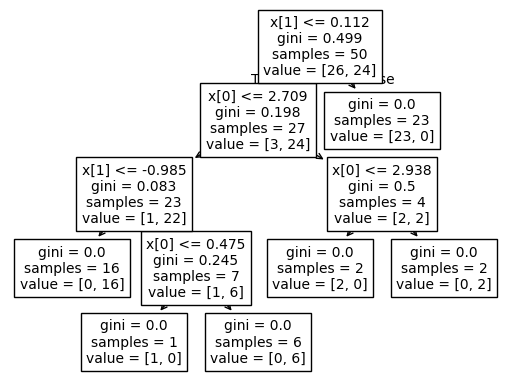

In [26]:


plot_tree(clf1)

[Text(0.5, 0.9285714285714286, 'x[1] <= -0.291\ngini = 0.493\nsamples = 50\nvalue = [28.0, 22.0]'),
 Text(0.16666666666666666, 0.7857142857142857, 'x[0] <= 1.421\ngini = 0.159\nsamples = 23\nvalue = [21, 2]'),
 Text(0.3333333333333333, 0.8571428571428572, 'True  '),
 Text(0.08333333333333333, 0.6428571428571429, 'gini = 0.0\nsamples = 13\nvalue = [13, 0]'),
 Text(0.25, 0.6428571428571429, 'x[0] <= 1.577\ngini = 0.32\nsamples = 10\nvalue = [8, 2]'),
 Text(0.16666666666666666, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.5, 'x[1] <= -1.178\ngini = 0.198\nsamples = 9\nvalue = [8, 1]'),
 Text(0.25, 0.35714285714285715, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.4166666666666667, 0.35714285714285715, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8333333333333334, 0.7857142857142857, 'x[1] <= 3.13\ngini = 0.384\nsamples = 27\nvalue = [7, 20]'),
 Text(0.6666666666666667, 0.8571428571428572, '  False'),
 Text(0.75, 0.6428571428571429, 'x[0] <= 1.0

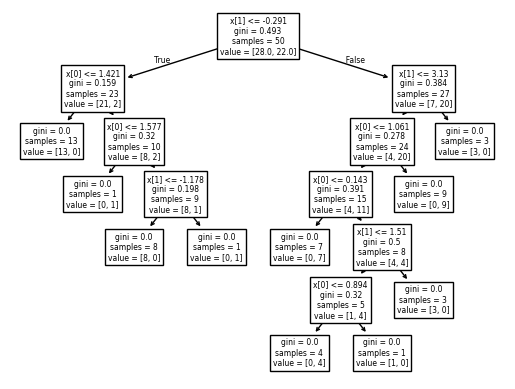

In [27]:
plot_tree(clf2)

[Text(0.375, 0.9166666666666666, 'x[0] <= -0.521\ngini = 0.5\nsamples = 50\nvalue = [25, 25]'),
 Text(0.25, 0.75, 'gini = 0.0\nsamples = 19\nvalue = [19, 0]'),
 Text(0.3125, 0.8333333333333333, 'True  '),
 Text(0.5, 0.75, 'x[1] <= 3.02\ngini = 0.312\nsamples = 31\nvalue = [6, 25]'),
 Text(0.4375, 0.8333333333333333, '  False'),
 Text(0.25, 0.5833333333333334, 'x[1] <= -1.64\ngini = 0.198\nsamples = 27\nvalue = [3, 24]'),
 Text(0.125, 0.4166666666666667, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.4166666666666667, 'x[0] <= -0.314\ngini = 0.077\nsamples = 25\nvalue = [1, 24]'),
 Text(0.25, 0.25, 'x[0] <= -0.381\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.125, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5, 0.25, 'gini = 0.0\nsamples = 23\nvalue = [0, 23]'),
 Text(0.75, 0.5833333333333334, 'x[1] <= 3.442\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.625

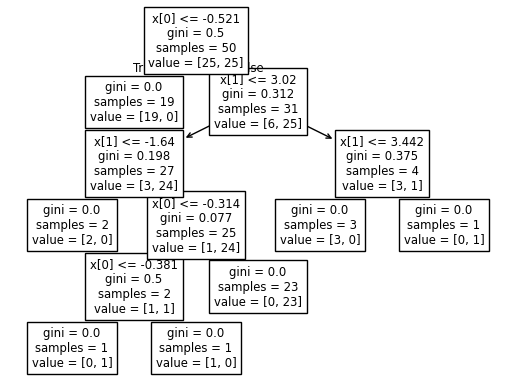

In [28]:
plot_tree(clf3)

In [29]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [30]:

clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [31]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [32]:


df.sample(14,replace=True)


,col1,col2,col3,col4,col5,target
51,-1.441536,2.219559,-0.290145,1.688178,-0.359972,1
61,-1.381098,0.041477,2.686827,0.813361,-1.247923,1
83,1.962541,0.884803,-0.699819,-1.017631,0.340301,0
3,-0.444845,-0.225278,1.338907,-0.191135,-1.418691,1
7,-3.603598,1.084429,3.102486,2.756127,1.040317,1
83,1.962541,0.884803,-0.699819,-1.017631,0.340301,0
61,-1.381098,0.041477,2.686827,0.813361,-1.247923,1
58,-0.030383,2.710925,-3.811629,-0.552780,-0.767126,0
38,-1.558564,0.251124,1.142481,1.220161,-0.696917,1
81,-1.750300,-0.235758,0.678258,0.935545,-0.629949,1
